# Chapter 4 — Regression and Prediction

Regression is used to describe relationships between variables and to
predict a response variable from one or more predictor variables.

The main topics in this chapter are:

- Simple linear regression
- Multiple linear regression
- Model assessment
- Cross-validation
- Model selection
- Prediction and prediction intervals
- Factor variables
- Multicollinearity and confounding
- Interactions
- Regression diagnostics
- Polynomial regression
- Spline regression
- Generalized additive models (GAMs)

Regression is an important connection between statistics and supervised
machine learning because a model can be trained using known outcomes and
then used to predict outcomes for new observations.

## 1. Simple Linear Regression

Simple linear regression models the relationship between one predictor X
and a response Y.

The regression equation is:

Y = b0 + b1X + e

where:

- Y is the response variable.
- X is the predictor variable.
- b0 is the intercept.
- b1 is the regression coefficient or slope.
- e represents the error.

The fitted regression line estimates the expected value of Y for a given X.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

# Small example illustrating a linear relationship.
simple_data = pd.DataFrame({
    'X': [1, 2, 3, 4, 5],
    'Y': [2.1, 4.0, 6.2, 7.9, 10.1]
})

model = LinearRegression()
model.fit(simple_data[['X']], simple_data['Y'])

print(f'Intercept: {model.intercept_:.3f}')
print(f'Slope: {model.coef_[0]:.3f}')

Intercept: 0.090
Slope: 1.990


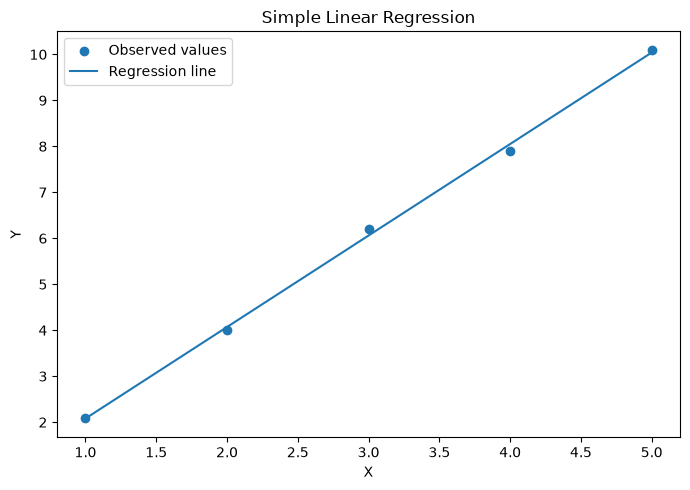

In [2]:
predicted = model.predict(simple_data[['X']])

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    simple_data['X'],
    simple_data['Y'],
    label='Observed values'
)

ax.plot(
    simple_data['X'],
    predicted,
    label='Regression line'
)

ax.set_title('Simple Linear Regression')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()

plt.tight_layout()
plt.show()

## 2. Fitted Values and Residuals

A fitted value is the value predicted by the regression model.

A residual is the difference between the observed value and the fitted
value:

Residual = Observed Value - Fitted Value

Residuals represent the prediction errors of the model.

A good regression model should generally leave residuals without an
obvious systematic pattern.

In [3]:
simple_results = simple_data.copy()

simple_results['Fitted'] = predicted
simple_results['Residual'] = (
    simple_results['Y'] - simple_results['Fitted']
)

display(simple_results.round(3))

,X,Y,Fitted,Residual
0,1,2.1,2.08,0.02
1,2,4.0,4.07,-0.07
2,3,6.2,6.06,0.14
3,4,7.9,8.05,-0.15
4,5,10.1,10.04,0.06


## 3. Least Squares

Ordinary least squares (OLS) fits the regression line by minimizing the
sum of squared residuals.

The objective is:

Sum of Squared Errors = Σ(yi - ŷi)²

Squaring the residuals prevents positive and negative errors from
cancelling each other and gives greater importance to larger errors.

The resulting line is the one that minimizes this total squared error.

In [4]:
sse = np.sum(
    (simple_results['Y'] - simple_results['Fitted']) ** 2
)

print(f'Sum of squared errors: {sse:.4f}')

Sum of squared errors: 0.0510


## 4. Prediction Versus Explanation

Regression can be used for two related but different purposes.

### Prediction

The goal is to accurately predict unknown outcomes.

### Explanation

The goal is to understand how predictors are associated with the response.

A regression relationship alone does not establish causation. A predictor
can be associated with an outcome without directly causing it.

For data science, predictive accuracy is often the primary concern.

## 5. Multiple Linear Regression

Multiple linear regression extends simple regression to several predictors.

The equation becomes:

Y = b0 + b1X1 + b2X2 + ... + bpXp + e

Each coefficient describes the expected change in Y for a one-unit
increase in that predictor while holding the other predictors constant.

Important model metrics include:

- RMSE — Root Mean Squared Error
- RSE — Residual Standard Error
- R² — Proportion of variance explained by the model

## 6. Example: King County Housing Data

The book uses King County house sales to demonstrate multiple linear
regression.

The objective is to predict adjusted sale price from characteristics
such as:

- Finished living area
- Lot size
- Number of bathrooms
- Number of bedrooms
- Building grade

In [10]:
# Load the King County housing dataset.
#
# The file is tab-separated even though its filename uses the .csv
# extension, so sep='\t' is required.

house = pd.read_csv(
    '../data/house_sales.csv',
    sep='\t'
)

predictors = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade'
]

outcome = 'AdjSalePrice'

print(f'Dataset shape: {house.shape}')

display(
    house[predictors + [outcome]].head()
)

Dataset shape: (22687, 22)


,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,AdjSalePrice
1,2400,9373,3.00,6,7,300805.0
2,3764,20156,3.75,4,10,1076162.0
3,2060,26036,1.75,4,8,761805.0
4,3200,8618,3.75,5,7,442065.0
5,1720,8620,1.75,4,7,297065.0


In [11]:
house_model = LinearRegression()

house_model.fit(
    house[predictors],
    house[outcome]
)

coefficient_table = pd.DataFrame({
    'Predictor': predictors,
    'Coefficient': house_model.coef_
})

print(f'Intercept: {house_model.intercept_:,.2f}')
display(coefficient_table.round(2))

Intercept: -521,871.37


,Predictor,Coefficient
0,SqFtTotLiving,228.83
1,SqFtLot,-0.06
2,Bathrooms,-19442.84
3,Bedrooms,-47769.96
4,BldgGrade,106106.96


## 7. Assessing the Model

RMSE measures the typical size of the prediction error:

RMSE = sqrt(Σ(yi - ŷi)² / n)

R² measures the proportion of variation in the response explained by the
model.

A model can have a high R² while still producing relatively large
prediction errors, so multiple metrics should be considered.

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

house_predictions = house_model.predict(
    house[predictors]
)

rmse = np.sqrt(
    mean_squared_error(
        house[outcome],
        house_predictions
    )
)

r_squared = r2_score(
    house[outcome],
    house_predictions
)

model_metrics = pd.Series({
    'RMSE': rmse,
    'R-squared': r_squared
})

display(
    model_metrics.to_frame('Value').style.format({
        'Value': '{:,.4f}'
    })
)

,Value
RMSE,"261,220.1974"
R-squared,0.5406


## 8. Cross-Validation

Evaluating a model on the same data used to train it can give an overly
optimistic estimate of predictive performance.

Cross-validation addresses this by repeatedly dividing the data into
training and validation portions.

The model is trained on one portion and evaluated on data that was not
used for that training iteration.

This provides a better estimate of how the model may perform on new data.

In [13]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    house_model,
    house[predictors],
    house[outcome],
    cv=5,
    scoring='neg_root_mean_squared_error'
)

cv_summary = pd.Series({
    'Mean CV RMSE': -cv_scores.mean(),
    'CV RMSE Std. Dev.': cv_scores.std()
})

display(
    cv_summary.to_frame('Value').style.format('{:,.2f}')
)

,Value
Mean CV RMSE,"260,404.55"
CV RMSE Std. Dev.,"26,767.64"


## 9. Model Selection and Stepwise Regression

When many predictors are available, not every variable needs to be
included in the final model.

Model selection attempts to find a useful subset of predictors.

Stepwise regression is one approach that adds or removes predictors
according to a chosen criterion.

The purpose is to obtain a model that balances predictive performance
with unnecessary complexity.

Model selection should be evaluated carefully because repeatedly testing
different models can lead to overfitting.

In [14]:
# Compare a smaller model with the full model.

reduced_predictors = [
    'SqFtTotLiving',
    'Bedrooms',
    'BldgGrade'
]

reduced_model = LinearRegression()

reduced_scores = cross_val_score(
    reduced_model,
    house[reduced_predictors],
    house[outcome],
    cv=5,
    scoring='neg_root_mean_squared_error'
)

model_comparison = pd.DataFrame({
    'Model': ['Full model', 'Reduced model'],
    'Mean CV RMSE': [
        -cv_scores.mean(),
        -reduced_scores.mean()
    ]
})

display(
    model_comparison.style.format({
        'Mean CV RMSE': '{:,.2f}'
    })
)

,Model,Mean CV RMSE
0,Full model,"260,404.55"
1,Reduced model,"260,536.24"


## 10. Weighted Regression

In weighted regression, observations receive different weights.

A larger weight gives an observation more influence on the fitted model.

Weights can be useful when some observations are more important or have
different levels of precision.

In [15]:
weighted_model = LinearRegression()

weights = np.ones(len(house))

weighted_model.fit(
    house[predictors],
    house[outcome],
    sample_weight=weights
)

print('Weighted regression model fitted successfully.')

Weighted regression model fitted successfully.


## 11. Prediction Using Regression

Once a regression model has been fitted, it can be used to predict the
response for new observations.

However, predictions outside the range of the training data are
extrapolations.

Extrapolation is dangerous because the relationship observed in the
training data may not continue outside the observed range.

In [16]:
# Example prediction for a hypothetical house.

new_house = pd.DataFrame({
    'SqFtTotLiving': [2000],
    'SqFtLot': [5000],
    'Bathrooms': [2.5],
    'Bedrooms': [3],
    'BldgGrade': [7]
})

predicted_price = house_model.predict(new_house)[0]

print(
    f'Predicted adjusted sale price: '
    f'${predicted_price:,.2f}'
)

Predicted adjusted sale price: $486,319.28


## 12. Confidence and Prediction Intervals

A confidence interval describes uncertainty around an estimated statistic
or mean response.

A prediction interval describes uncertainty around a prediction for an
individual future observation.

Prediction intervals are generally wider because they include both:

- Uncertainty in the estimated mean
- Individual observation variability

Therefore, a confidence interval should not be interpreted as though it
were an interval for an individual prediction.

## 13. Factor Variables in Regression

Factor variables are categorical variables with a limited number of
possible values.

Examples include:

- Property type
- Region
- Department
- Product category

Linear regression requires numerical inputs, so categorical variables
must be represented numerically.

A common approach is dummy-variable encoding.

For a factor with P levels, regression normally uses P - 1 dummy
variables when an intercept is included.

One level acts as the reference category.

In [17]:
property_dummies = pd.get_dummies(
    house['PropertyType'],
    drop_first=True
)

display(property_dummies.head())

,Single Family,Townhouse
1,False,False
2,True,False
3,True,False
4,True,False
5,True,False


In [18]:
factor_predictors = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade',
    'PropertyType'
]

X_factor = pd.get_dummies(
    house[factor_predictors],
    drop_first=True
)

factor_model = LinearRegression()

factor_model.fit(
    X_factor,
    house[outcome]
)

factor_coefficients = pd.DataFrame({
    'Predictor': X_factor.columns,
    'Coefficient': factor_model.coef_
})

display(factor_coefficients.round(2))

,Predictor,Coefficient
0,SqFtTotLiving,223.37
1,SqFtLot,-0.07
2,Bathrooms,-15979.01
3,Bedrooms,-50889.73
4,BldgGrade,109416.31
5,PropertyType_Single Family,-84678.22
6,PropertyType_Townhouse,-115121.98


## 14. Correlated Predictors and Multicollinearity

Predictors in a multiple regression model can be correlated with one
another.

This makes individual coefficients more difficult to interpret because
the predictors contain overlapping information.

Multicollinearity is an extreme form of this problem where predictors
are highly or perfectly correlated.

For example, house size, number of bedrooms, and number of bathrooms can
be related.

Multicollinearity can make regression coefficients unstable and increase
their standard errors.

In [19]:
correlation_matrix = house[
    ['SqFtTotLiving', 'SqFtLot', 'Bathrooms',
     'Bedrooms', 'BldgGrade']
].corr()

display(
    correlation_matrix.style.format('{:.2f}')
)

,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
SqFtTotLiving,1.00,0.20,0.76,0.60,0.77
SqFtLot,0.20,1.00,0.11,0.07,0.15
Bathrooms,0.76,0.11,1.00,0.54,0.66
Bedrooms,0.60,0.07,0.54,1.00,0.37
BldgGrade,0.77,0.15,0.66,0.37,1.00


## 15. Confounding Variables

A confounding variable is an important predictor that is omitted from
the regression model.

This omission can make other coefficients appear to represent a
relationship that is actually influenced by the missing variable.

In the King County housing example, location is important because houses
with similar physical characteristics can have very different values
depending on where they are located.

## 16. Interactions and Main Effects

A main effect describes the relationship between one predictor and the
response while accounting for the other variables in the model.

An interaction occurs when the effect of one predictor depends on the
value of another predictor.

For example, the effect of house size on sale price may depend on the
location of the house.

In [27]:
# Fit a regression model with an interaction between
# living area and location group.

interaction_model = smf.ols(
    formula=(
        'AdjSalePrice ~ SqFtTotLiving * ZipGroup '
        '+ SqFtLot + Bathrooms + Bedrooms + BldgGrade '
        '+ PropertyType'
    ),
    data=house
).fit()

print(
    f'Interaction model R-squared: '
    f'{interaction_model.rsquared:.3f}'
)

Interaction model R-squared: 0.682


## 17. Regression Diagnostics

Regression diagnostics examine whether individual observations or
patterns in the residuals may be affecting the model.

Important diagnostic concepts include:

- Standardized residuals
- Outliers
- Influential observations
- Leverage
- Heteroskedasticity
- Non-normal residuals
- Correlated errors
- Partial residual plots

These diagnostics are particularly useful when trying to understand why
a model behaves unexpectedly.

## 18. Outliers and Influential Values

An outlier has a response value that is unusually far from the value
predicted by the regression model.

An influential observation is a record whose removal would substantially
change the fitted regression equation.

A point can therefore be influential without having an unusually large
residual.

Leverage measures how unusual an observation's predictor values are.

In [21]:
from statsmodels.api import OLS, add_constant
from statsmodels.stats.outliers_influence import OLSInfluence

house_clean = house.dropna(
    subset=predictors + [outcome]
).copy()

X = add_constant(house_clean[predictors])
y = house_clean[outcome]

diagnostic_model = OLS(y, X).fit()

influence = OLSInfluence(diagnostic_model)

diagnostics = pd.DataFrame({
    'Studentized Residual':
        influence.resid_studentized_internal,
    'Cook Distance':
        influence.cooks_distance[0],
    'Leverage':
        influence.hat_matrix_diag
})

display(
    diagnostics.sort_values(
        'Cook Distance',
        ascending=False
    ).head(5)
)

,Studentized Residual,Cook Distance,Leverage
7278,6.406701,0.604632,0.081207
20115,36.292885,0.401249,0.001824
11945,21.754145,0.257853,0.003259
16634,15.485212,0.241134,0.005997
11151,17.298400,0.179517,0.003587


## 19. Heteroskedasticity and Non-Normality

Heteroskedasticity occurs when the variance of residuals changes across
different ranges of predicted values or predictors.

A residual plot can help reveal this pattern.

Non-normal residuals can affect some formal statistical inference, although
the book notes that this is often less important when the primary goal is
prediction rather than formal inference.

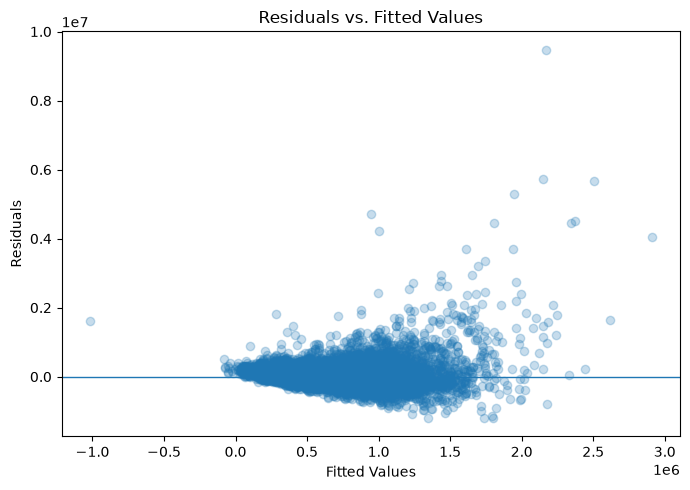

In [22]:
residuals = diagnostic_model.resid
fitted_values = diagnostic_model.fittedvalues

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    fitted_values,
    residuals,
    alpha=0.25
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_title('Residuals vs. Fitted Values')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')

plt.tight_layout()
plt.show()

## 20. Polynomial Regression

A linear relationship may not adequately describe the relationship
between a predictor and response.

Polynomial regression adds powers of a predictor.

For example:

Y = b0 + b1X + b2X² + e

The squared term allows the fitted relationship to curve.

Higher-order polynomials can model more complex curves, but excessive
polynomial terms can produce undesirable "wiggliness".

In [23]:
house_98105 = house.loc[
    house['ZipCode'] == 98105
].dropna(
    subset=[
        'AdjSalePrice',
        'SqFtTotLiving',
        'SqFtLot',
        'Bathrooms',
        'Bedrooms',
        'BldgGrade'
    ]
)

polynomial_model = smf.ols(
    formula=(
        'AdjSalePrice ~ SqFtTotLiving '
        '+ I(SqFtTotLiving**2) '
        '+ SqFtLot + Bathrooms + Bedrooms + BldgGrade'
    ),
    data=house_98105
).fit()

print(
    f'Polynomial model R-squared: '
    f'{polynomial_model.rsquared:.3f}'
)

Polynomial model R-squared: 0.806


## 21. Splines

Splines provide another way to model nonlinear relationships.

Instead of fitting one high-degree polynomial across the entire range,
splines use piecewise polynomial functions joined smoothly at points
called knots.

Splines can therefore provide flexible curves without requiring a single
high-degree polynomial.

In [24]:
from patsy import bs

spline_model = smf.ols(
    formula=(
        'AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) '
        '+ SqFtLot + Bathrooms + Bedrooms + BldgGrade'
    ),
    data=house_98105
).fit()

print(
    f'Spline model R-squared: '
    f'{spline_model.rsquared:.3f}'
)

Spline model R-squared: 0.814


## 22. Generalized Additive Models

Generalized additive models (GAMs) allow nonlinear relationships to be
modeled using smooth functions of individual predictors.

They provide more flexibility than a purely linear model while retaining
an additive structure.

The important idea is that the relationship between a predictor and the
response does not necessarily need to be a straight line.

# Chapter 4 Summary

Regression provides a way to model relationships between a response
variable and one or more predictors.

This chapter covered:

- Simple linear regression
- Regression equations
- Fitted values and residuals
- Least squares
- Prediction versus explanation
- Multiple linear regression
- RMSE and R²
- Cross-validation
- Model selection
- Weighted regression
- Prediction and extrapolation
- Confidence and prediction intervals
- Factor variables and dummy variables
- Correlated predictors
- Multicollinearity
- Confounding variables
- Main effects and interactions
- Regression diagnostics
- Outliers and influential observations
- Heteroskedasticity and non-normality
- Polynomial regression
- Splines
- Generalized additive models

The main lesson is that fitting a regression model is only the first
step. A useful analysis also requires evaluating prediction accuracy,
understanding the predictors, checking the model for problematic
observations or patterns, and recognizing when a linear relationship is
too restrictive.